In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
#!wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv

In [3]:
df = pd.read_csv("car_fuel_efficiency_2026.csv")
df

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,2005,USA,Gasoline,All-wheel drive,4,2470,6,271.0,4690,18.9,27.4
9996,1993,Asia,Gasoline,All-wheel drive,2,2300,6,244.0,4370,19.0,30.0
9997,2014,USA,Gasoline,All-wheel drive,3,2480,6,267.0,4590,18.4,28.1
9998,2004,USA,Hybrid,Rear-wheel drive,5,2180,6,270.0,4450,20.9,32.2


In [4]:
col_list = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']

In [5]:
df = df[col_list]
df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


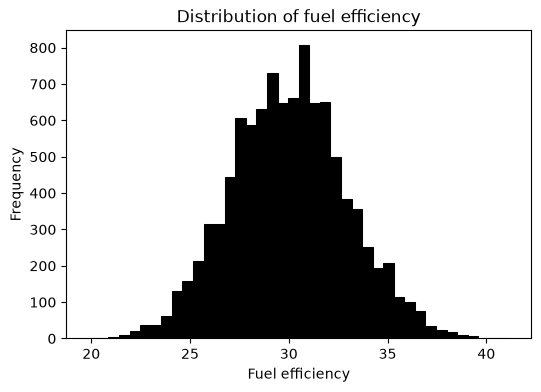

In [6]:
plt.figure(figsize=(6, 4))

sns.histplot(df.fuel_efficiency_mpg, bins=40, color='black', alpha=1)
plt.ylabel('Frequency')
plt.xlabel('Fuel efficiency')
plt.title('Distribution of fuel efficiency')

plt.show()

In [7]:
df.describe()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,10000.000000,9123.000000,10000.000000,10000.000000,10000.000000
mean,2268.807000,254.446016,4286.754000,1999.549500,29.997700
std,183.447355,22.844613,266.212491,14.207925,2.930245
min,1590.000000,171.000000,3320.000000,1975.000000,19.800000
25%,2150.000000,239.000000,4110.000000,1987.000000,28.000000
50%,2270.000000,254.000000,4280.000000,2000.000000,30.000000
75%,2390.000000,270.000000,4470.000000,2012.000000,31.900000
max,3110.000000,334.000000,5460.000000,2024.000000,41.200000


### 1. Missing values

In [8]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

### 2. Median for horsepower

In [9]:
df.horsepower.describe()

count    9123.000000
mean      254.446016
std        22.844613
min       171.000000
25%       239.000000
50%       254.000000
75%       270.000000
max       334.000000
Name: horsepower, dtype: float64

### 3. Filling NAs

In [10]:
def split_df(df, seed, train=0.6, val=0.2, test=0.2):
    np.random.seed(seed)

    n = len(df)
    idx = np.arange(n)
    np.random.shuffle(idx)    
    
    n_val = int(n * val)
    n_test = int(n * test)
    n_train = n - n_val - n_test

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    
    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

    return df_train, df_val, df_test

In [11]:
def get_targets(df):
    y = df['fuel_efficiency_mpg'].values
    
    del df['fuel_efficiency_mpg']

    return y

In [12]:
seed = 42
df_train, df_val, df_test = split_df(df, seed=seed)

In [13]:
df_train

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,1900,239.0,3790,2015,32.5
1,2000,224.0,4380,1992,29.1
2,2330,286.0,4090,2022,34.1
3,2300,NaN,4150,1997,30.6
4,2340,269.0,4400,2001,30.7
...,...,...,...,...,...
5995,2280,242.0,4590,2018,29.8
5996,2300,NaN,4240,1984,25.1
5997,2240,255.0,4190,1989,27.7
5998,2430,254.0,4280,2020,31.6


In [14]:
y_train = get_targets(df_train)
y_val = get_targets(df_val)
y_test = get_targets(df_test)

In [15]:
y_train

array([32.5, 29.1, 34.1, ..., 27.7, 31.6, 28. ], shape=(6000,))

In [16]:
# Linear Regression

def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [17]:
def prepare_X(df, nan_value=0):
    return df.fillna(nan_value).values

In [18]:
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [19]:
# fillna(0)

X_train = prepare_X(df_train, nan_value=0)
w_0, w = train_linear_regression(X_train, y_train)

In [20]:
y_pred = w_0 + X_train.dot(w)

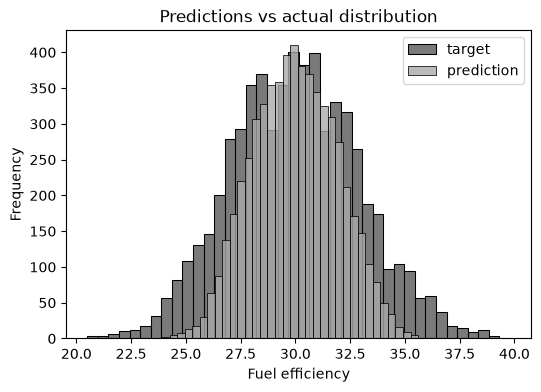

In [21]:
plt.figure(figsize=(6, 4))

sns.histplot(y_train, label='target', color='#222222', alpha=0.6, bins=40)
sns.histplot(y_pred, label='prediction', color='#aaaaaa', alpha=0.8, bins=40)

plt.legend()

plt.ylabel('Frequency')
plt.xlabel('Fuel efficiency')
plt.title('Predictions vs actual distribution')

plt.show()

In [22]:
rmse(y_train, y_pred)

np.float64(2.200184683371397)

In [23]:
X_val = prepare_X(df_val, nan_value=0)
y_pred = w_0 + X_val.dot(w)

In [24]:
rmse_0 = rmse(y_val, y_pred)
rmse_0

np.float64(2.205293194751098)

In [25]:
# fillna(mean)

mean_value = df_train.horsepower.mean()

X_train = prepare_X(df_train, nan_value=mean_value)
w_0, w = train_linear_regression(X_train, y_train) 

In [26]:
y_pred = w_0 + X_train.dot(w)

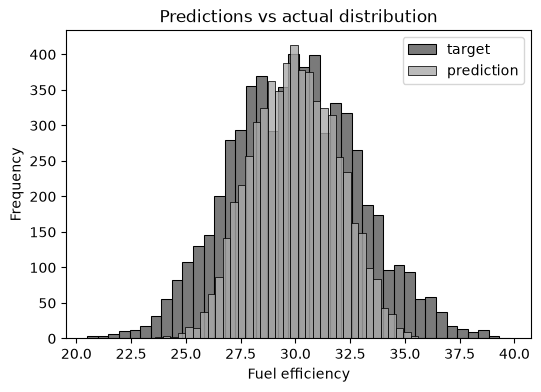

In [27]:
plt.figure(figsize=(6, 4))

sns.histplot(y_train, label='target', color='#222222', alpha=0.6, bins=40)
sns.histplot(y_pred, label='prediction', color='#aaaaaa', alpha=0.8, bins=40)

plt.legend()

plt.ylabel('Frequency')
plt.xlabel('Fuel efficiency')
plt.title('Predictions vs actual distribution')

plt.show()

In [28]:
rmse(y_train, y_pred)

np.float64(2.198101430917093)

In [29]:
X_val = prepare_X(df_val, nan_value=mean_value)
y_pred = w_0 + X_val.dot(w)

In [30]:
rmse_mean = rmse(y_val, y_pred)
rmse_mean

np.float64(2.201817484568115)

In [31]:
print("rmse_0:", rmse_0)
print("rmse_mean:", rmse_mean)

rmse_0: 2.205293194751098
rmse_mean: 2.201817484568115


### 4. Best regularization

In [32]:
seed = 42
r_list = [0, 0.01, 0.1, 1, 5, 10, 100]

In [33]:
df_train, df_val, df_test = split_df(df, seed=seed)
    
y_train = get_targets(df_train)
y_val = get_targets(df_val)
y_test = get_targets(df_test)

In [34]:
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [35]:
X_train = prepare_X(df_train, nan_value=0)

In [36]:
for r in r_list:
    w_0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val, nan_value=mean_value)
    y_pred = w_0 + X_val.dot(w)

    rmse_value = rmse(y_val, y_pred)
    
    print('%5s, %.4f' % (r, round(rmse_value, 4)))

    0, 2.2053
 0.01, 2.2052
  0.1, 2.2219
    1, 2.3564
    5, 2.4226
   10, 2.4338
  100, 2.4445


### 5. RMSE standard deviation

In [37]:
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

rmse_scores = []

for seed in seeds:    
    df_train, df_val, df_test = split_df(df, seed=seed)
    
    y_train = get_targets(df_train)
    y_val = get_targets(df_val)
    y_test = get_targets(df_test)

    X_train = prepare_X(df_train, nan_value=0)
    w_0, w = train_linear_regression(X_train, y_train)

    X_val = prepare_X(df_val, nan_value=0)
    y_pred = w_0 + X_val.dot(w)

    rmse_scores.append(rmse(y_val, y_pred))

rmse_scores

[np.float64(2.2392041430461465),
 np.float64(2.2021128210838907),
 np.float64(2.163419778753095),
 np.float64(2.2043588768539144),
 np.float64(2.2018800943312926),
 np.float64(2.2457851509084974),
 np.float64(2.269721207952404),
 np.float64(2.190794599933433),
 np.float64(2.2166112016864443),
 np.float64(2.207036592817851)]

In [38]:
std = np.std(rmse_scores)
std

np.float64(0.028781274078187116)

In [39]:
round(std, 3)

np.float64(0.029)

### 6. Evaluation on test

In [40]:
seed = 9
r=0.001

In [41]:
df_train, df_val, df_test = split_df(df, seed=seed)

y_train = get_targets(df_train)
y_val = get_targets(df_val)
y_test = get_targets(df_test)

In [42]:
df_train_full = pd.concat([df_train, df_val])
df_train_full = df_train_full.reset_index(drop=True)
df_train_full

,engine_displacement,horsepower,vehicle_weight,model_year
0,2320,246.0,4100,2014
1,2230,252.0,4250,1998
2,2700,276.0,4490,2008
3,2220,269.0,4060,2004
4,2370,NaN,4690,1979
...,...,...,...,...
7995,2690,324.0,4510,2023
7996,1920,190.0,4000,1998
7997,1800,225.0,3980,1994
7998,1970,232.0,3560,2009


In [43]:
y_train_full = np.concatenate([y_train, y_val])
y_train_full

array([32.5, 33.2, 32.4, ..., 29.1, 32.2, 35.6], shape=(8000,))

In [44]:
X_train_full = prepare_X(df_train_full, nan_value=0)

In [45]:
w0, w = train_linear_regression_reg(X_train_full, y_train_full, r=r)

In [46]:
X_test = prepare_X(df_test, nan_value=0)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
score

np.float64(2.2358277471917636)

In [47]:
round(score, 3)

np.float64(2.236)